# Quality toolbox

In [1]:
# Import library needed
#import functions
import numpy as np
import matplotlib.pyplot as plt

from NEUREQUA import *


from NEUREQUA import cognitive_module as cog 
from NEUREQUA import quality_module as quality

## Load data and parameters

In [2]:
# Parameters of the session you analyze

# Name or number of the subject you analyze
sub = 'sub-97'
# Name of the session you analyze
sess = 'sess-1'

In [3]:
# Path to data - This is the only thing you have to change to run the script


# Path where your micro data are stored (.dat, .medd, .nsX, .ncs)
dataFolder=r'C:\Users\dornier\PhD\Article\NeuReQua\Analyses\Sub-97\ncs/'
#dataFolder=r'F:\Screening\database\sub-97\sess-1\ncs/' 

# Path where you want to store figures and results
saveFolder=r'C:\Users\dornier\PhD\Article\NeuReQua\Analyses\Sub-97\Quality_Metrics/'

# path to excel file for the RMS tracking, only one excel is used per patient, all RMS data for the SEEG will be trancked on a single file

trackingtbl =r'C:\Users\dornier\PhD\Article\NeuReQua\Analyses\Sub-97/Metrics_Sub-97_Sess-1.xlsx'


In [ ]:
# Load data 
# Give the path folder where the files of micro-electrodes are stored
raw_data, data = quality.load_raw_data(dataFolder,dtype='ncs',length='all',pattern2exclude='_sub.ncs')


In [ ]:
# Determine parameters from the recording
sr = int(raw_data.info['sfreq'])
print("Your recording has a sampling rate of: " + str(sr) +" Hz")

In [ ]:
duration_min  = int(raw_data.__len__()/sr/60)

print("L'enregistrement a duré : "+str(duration_min)+" minutes")

In [ ]:
# Display the name of your electrodes

chRegions = np.array(raw_data.ch_names)
print(chRegions)

In [ ]:
# Re-order channels and data if there is more than two tetrode on a shaft
chRegions, data = quality.reorder_data(chRegions,data)


print(chRegions)

In [ ]:
# Prepare the tracking file

quality.tblprep(trackingtbl,chRegions,sub,sess)

## Quality analysis of the signal

In [ ]:
# Get the power spectrum of each channel 
p_welch = quality.p_welch(data,chRegions,sub,sess,sr,sr_down=1,fr_low=1,fr_high=90,saveFolder=saveFolder,probe_type='Dixi')

In [ ]:
# Get the level of noise of the recording for each channel (not displayed in the notebook)
quality.plot_noise(data,sr,chRegions,saveFolder)


In [ ]:
# Compute RMS on filtered signal
quality.rms_signal_filtered(data,trackingtbl,chRegions,sub,sess,fr_low=300,fr_high=3000,sr=sr,saveFolder=saveFolder) 

In [ ]:
# Compute correlation between neighbouring channels

correlation = quality.correlation_coefficient(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

In [ ]:
# Compute variance normalized by variance of neighbouring channels
quality.variance_normalized(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

In [ ]:
quality.deviation(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

In [ ]:
quality.variance(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [ ]:
quality.kurtosis(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [ ]:
quality.hurst_component(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [ ]:
SNR = quality.signaltonoise(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [ ]:
# Test on artefacts
from NEUREQUA import artefact_detections

test = list()

for iTetrode in range(int(data.shape[0]/4)):
    num_canalTetrode = (iTetrode*4,iTetrode*4+1,iTetrode*4+2,iTetrode*4+3)

    test.append(num_canalTetrode)

tetInds = test 

# Movement artefacts
badWins_movement = artefact_detections.detect_movement_artifacts(chTraces=data,chGoodInds=list(range(len(chRegions))),
                                                                tetInds=tetInds,verbose=False,SR=32768)


# Detect subtle artefacts
badWins_subtle = artefact_detections.detect_subtle_artifacts(chTraces=data,chGoodInds=np.array(list(range(len(chRegions)))),
                                                            tetInds= tetInds,chRegs=chRegions,SR=32768,verbose=False)

# Step 3: Merge detected windows using intersection
badWins_final = artefact_detections.get_timeWinsIntersect(badWins_movement, badWins_subtle, data.shape[1])


# Step 4: Print percentage of artefacted signal
artefact_detections.ratio_artefact(data,badWins_final,trackingtbl,sub,sess)

# Cognitive analyses of experiment

In [4]:
# Step 1 - Create the file with raw data
raw, metadata = cog.load_neuralynx_micro(dataFolder,sub,sess)

Found 32 .ncs file(s) in 'C:\Users\dornier\PhD\Article\NeuReQua\Analyses\Sub-97\ncs/'
Excluding channels matching pattern: '*_sub'
  → 0 macrocontact channel(s) excluded
  → 32 microwire channel(s) retained
File already exist

── Recording summary ──────────────────────────────
  Channels   : 32
  Samp. rate : 32768 Hz
  Duration   : 2929.7 s (48.83 min)
  Samples    : 96,001,104
  Data shape : (32, 96001104)  (channels × samples)
  Channel labels:
    • dtb1
    • dtb2
    • dtb3
    • dtb4
    • dtb5
    • dtb6
    • dtb7
    • dtb8
    • dtp1
    • dtp2
    • dtp3
    • dtp4
    • dtp5
    • dtp6
    • dtp7
    • dtp8
    • vb1
    • vb2
    • vb3
    • vb4
    • vb5
    • vb6
    • vb7
    • vb8
    • vtp1
    • vtp2
    • vtp3
    • vtp4
    • vtp5
    • vtp6
    • vtp7
    • vtp8
───────────────────────────────────────────────────



c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:120: UserWarning: Unable to parse original file path from Neuralynx header: -FileType Event
  warnings.warn('Unable to parse original file path from Neuralynx header: ' + hdr_lines[1])
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileVersion 3.2
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileUUID ea1efbb1-18e4-46d9-947a-72a17526a4cc
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:134: UserWarning: Unable to parse parameter line from Neuralynx header: -TimeCreated 2023/03/28 11:40:20
  warnings.warn('Unable to parse parameter line from Neuralynx header: ' + line)
c:\Users\

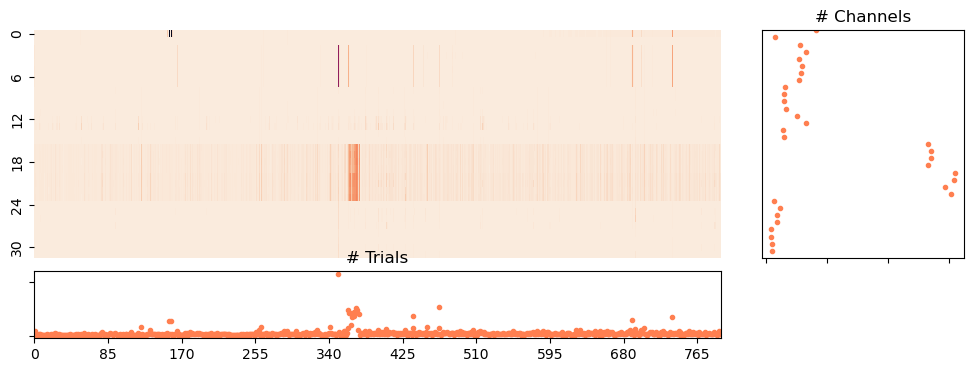

In [5]:
cog.plot_artefact_map(dataFolder,sub,sess)

c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:120: UserWarning: Unable to parse original file path from Neuralynx header: -FileType Event
  warnings.warn('Unable to parse original file path from Neuralynx header: ' + hdr_lines[1])
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileVersion 3.2
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileUUID ea1efbb1-18e4-46d9-947a-72a17526a4cc
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:134: UserWarning: Unable to parse parameter line from Neuralynx header: -TimeCreated 2023/03/28 11:40:20
  warnings.warn('Unable to parse parameter line from Neuralynx header: ' + line)
c:\Users\

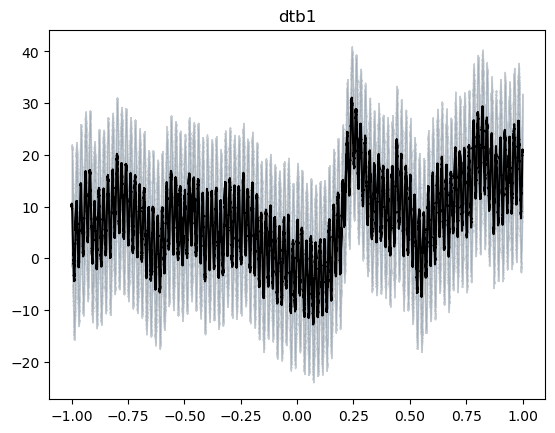

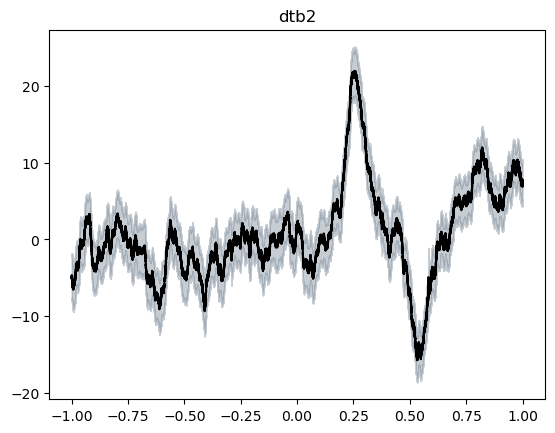

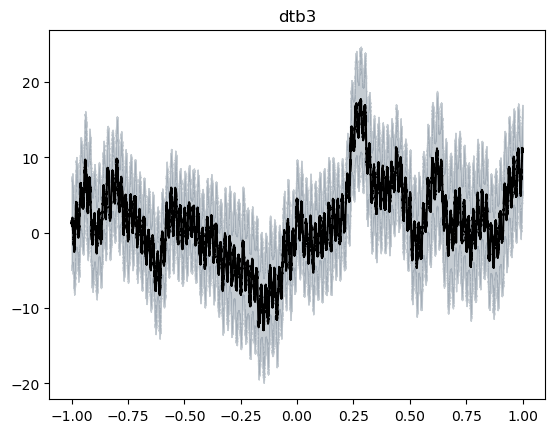

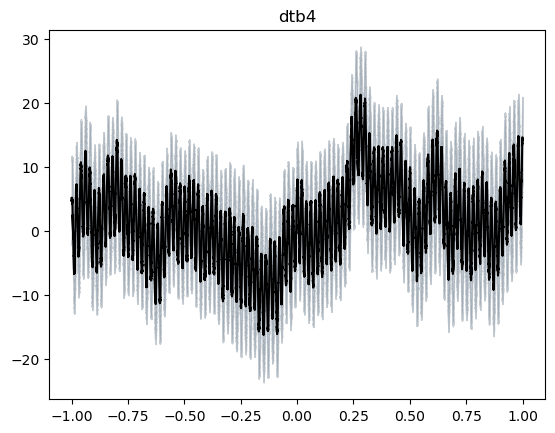

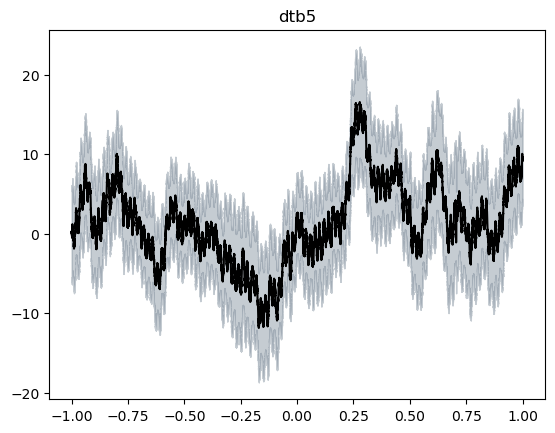

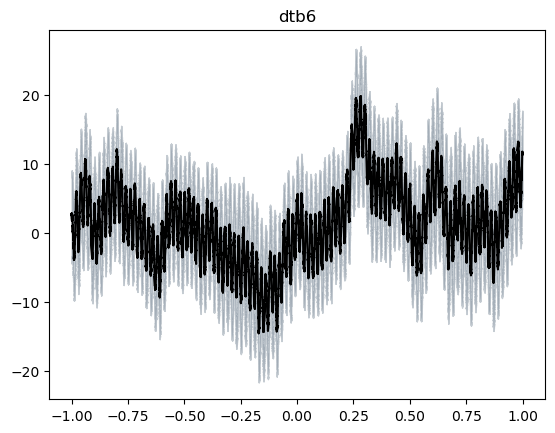

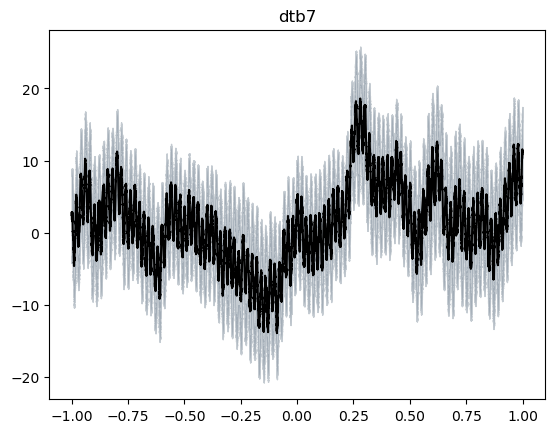

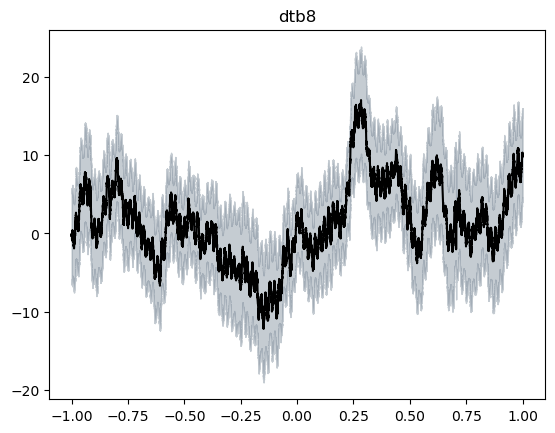

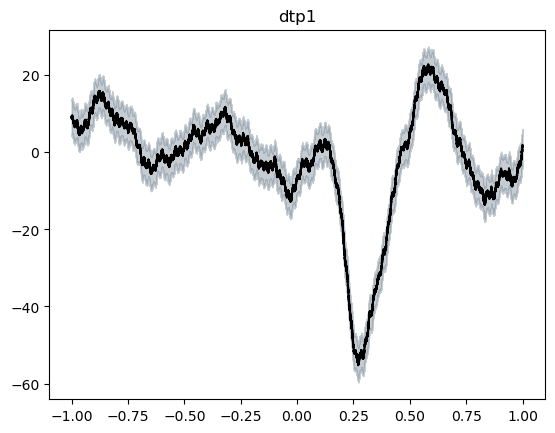

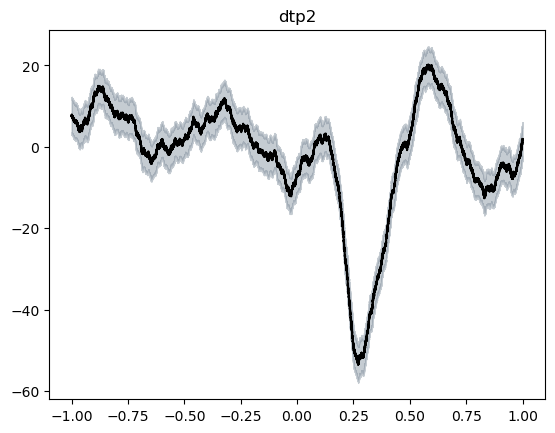

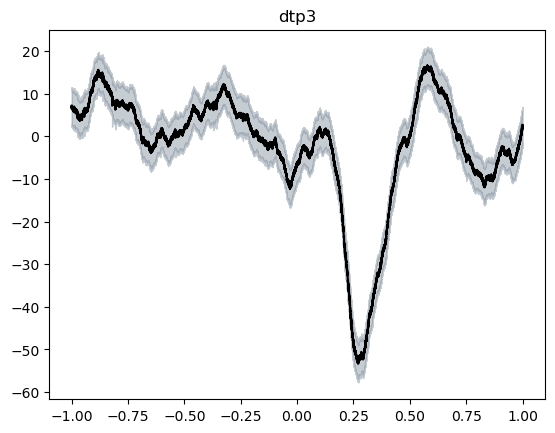

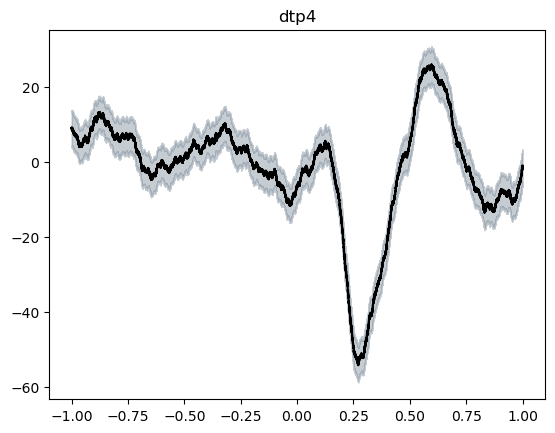

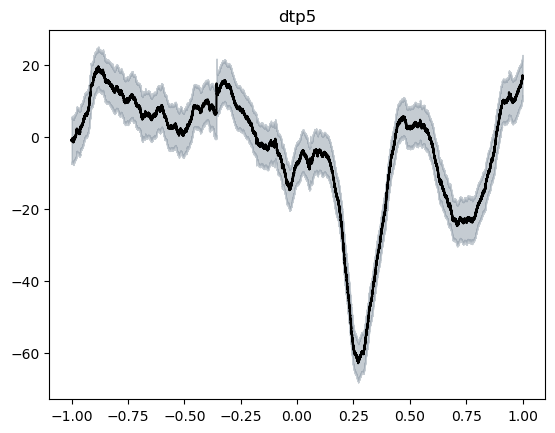

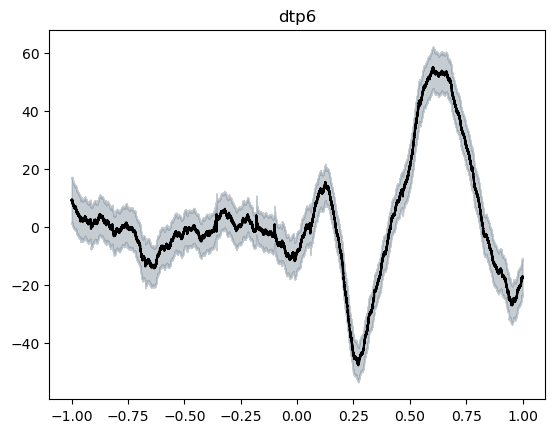

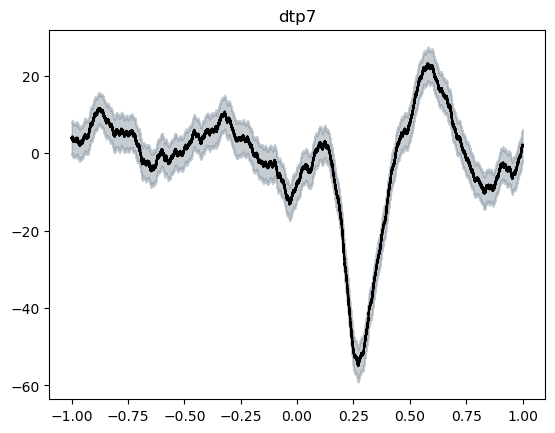

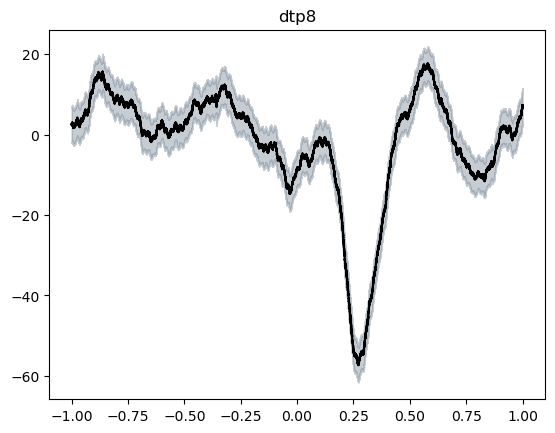

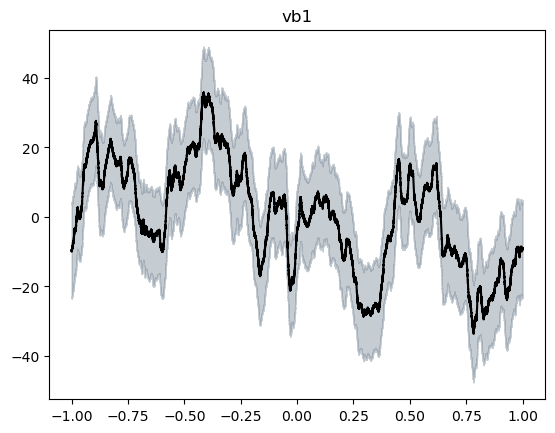

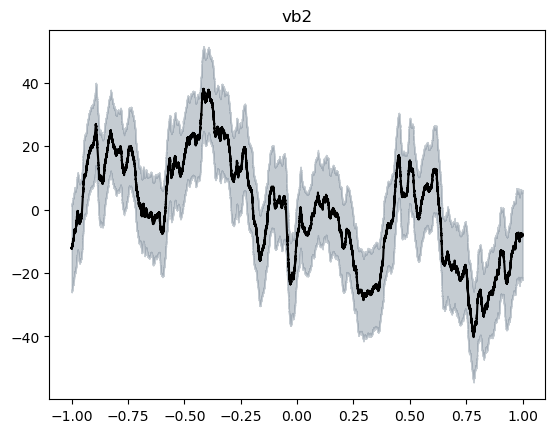

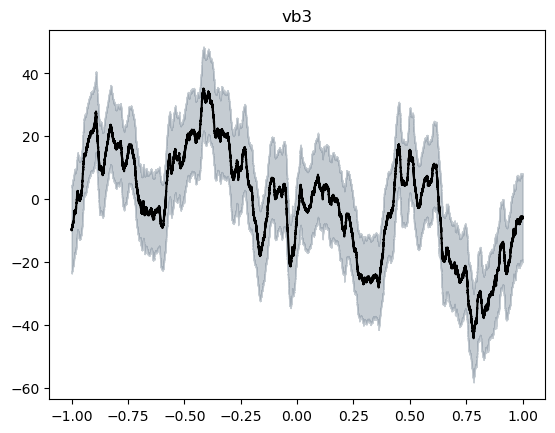

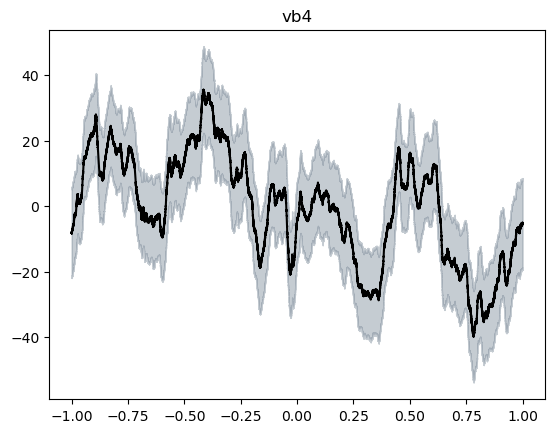

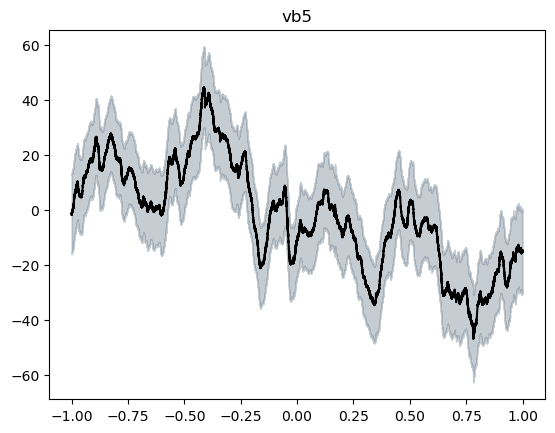

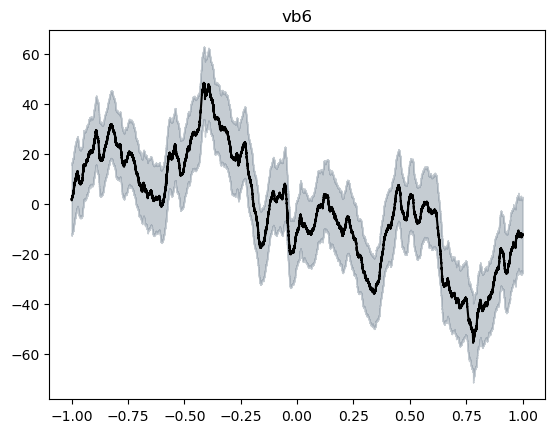

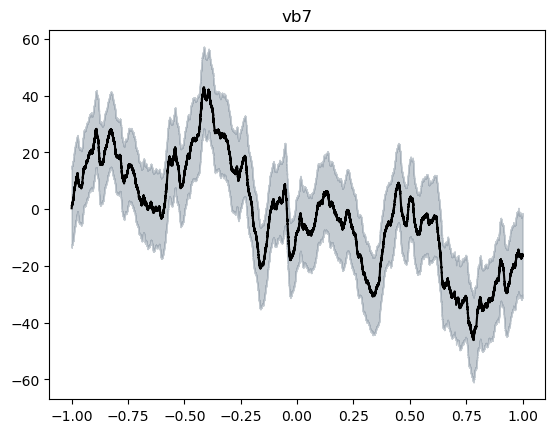

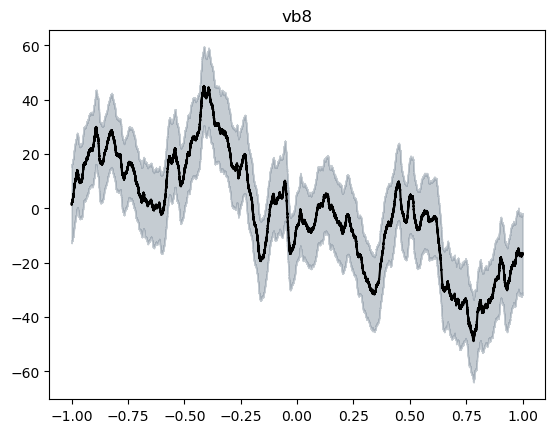

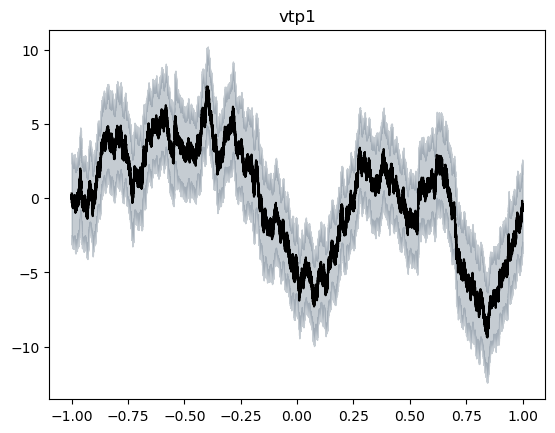

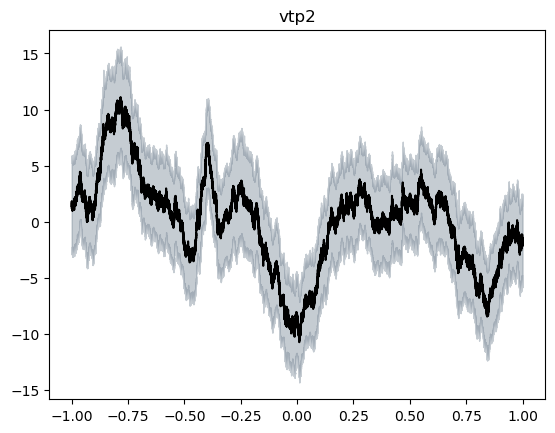

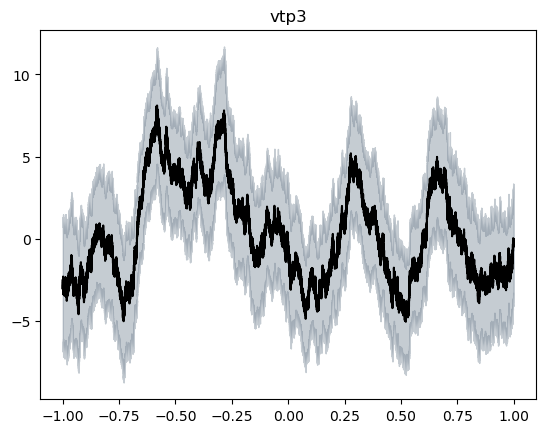

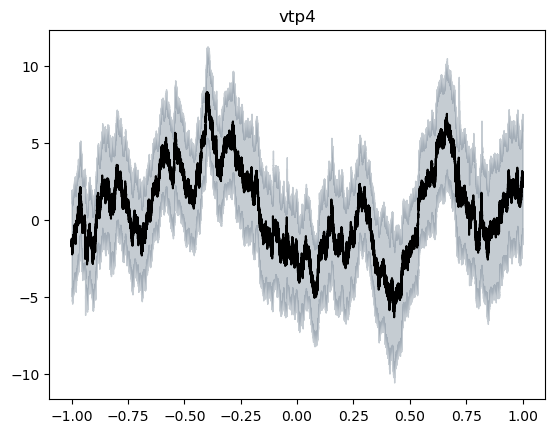

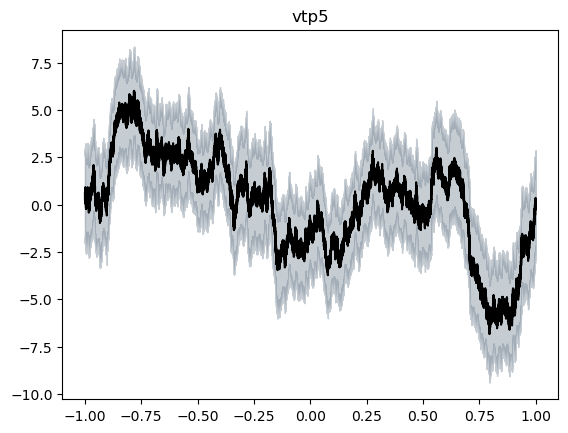

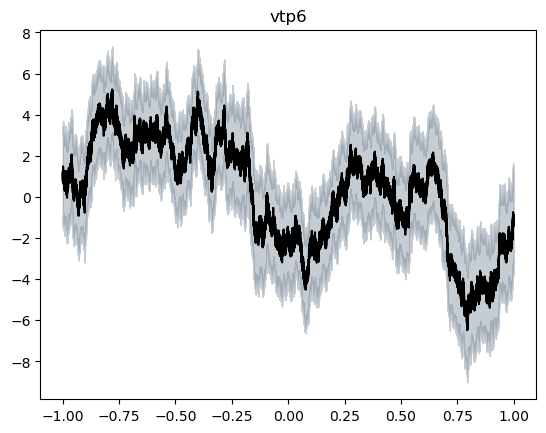

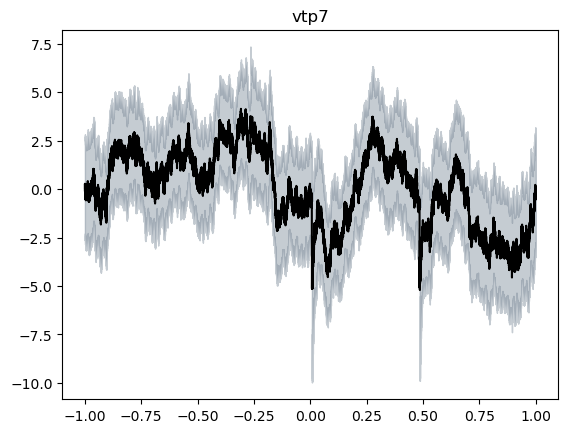

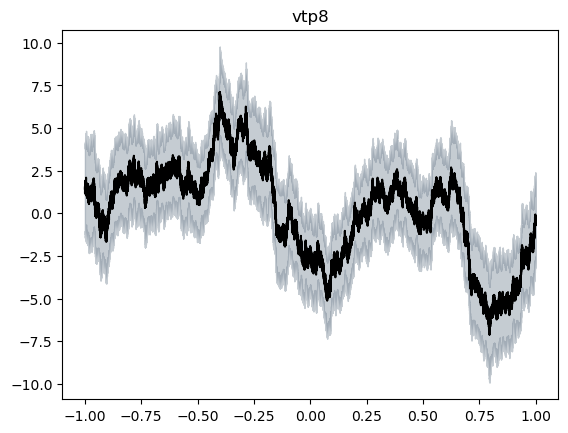

In [ ]:
import scipy.stats as stats

path = dataFolder

# Check whether the specified path exists or not
cog.ensure_dir(path)


lfps = cog.ensure_raw(path,sub,sess)
    
# Then create epoch
epoch_data = cog.create_epoch(lfps,path,t_min=1, t_max=1)

# Get the mean activity across trials for each channels
mean_channels = np.mean(epoch_data,axis=0)

# Get error standard
sem_channels = stats.sem(epoch_data,axis=0)

time = np.linspace(-1,1,mean_channels.shape[1])

nChannels = mean_channels.shape[0]

for iChannels in range(nChannels):

    fig, ax = plt.subplots(1,1,layout='constrained')

    ax.plot(time,mean_channels[iChannels],color='black')
    ax.fill_between(time,mean_channels[iChannels]-sem_channels[iChannels],
                     mean_channels[iChannels]+sem_channels[iChannels],
                     color='slategrey',alpha=0.4)
    
    ax.set_title(metadata['ch_names'][iChannels])
    




In [14]:
sem_channels.shape

(32, 65536)

In [11]:
mean_channels = np.mean(epoch,axis=0)

In [12]:
mean_channels.shape

(32, 65536)

c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:120: UserWarning: Unable to parse original file path from Neuralynx header: -FileType Event
  warnings.warn('Unable to parse original file path from Neuralynx header: ' + hdr_lines[1])
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileVersion 3.2
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileUUID ea1efbb1-18e4-46d9-947a-72a17526a4cc
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:134: UserWarning: Unable to parse parameter line from Neuralynx header: -TimeCreated 2023/03/28 11:40:20
  warnings.warn('Unable to parse parameter line from Neuralynx header: ' + line)
c:\Users\

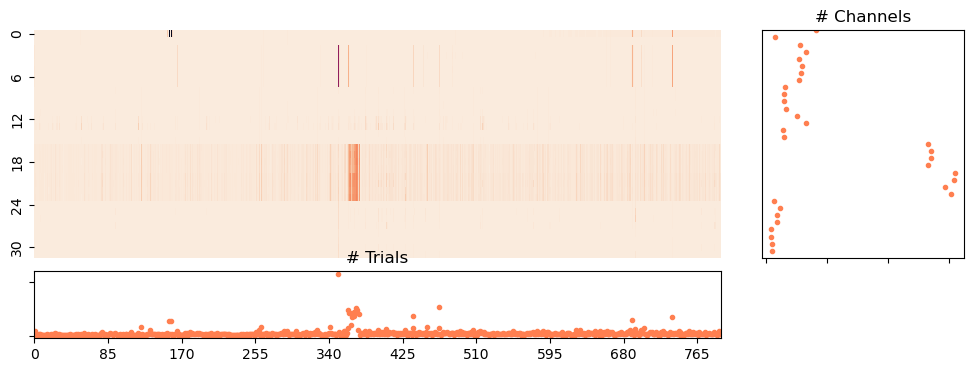

In [5]:
cog.plot_artefact_map(dataFolder,sub,sess)

In [5]:
# Import librairies

from __future__ import division

import os
import warnings
import numpy as np
import datetime
import random
import neo.rawio
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import seaborn as sb
import os
import neo
import mne
import pandas as pd
import scipy.stats as stats
import matplotlib
from typing import Optional
import json
import h5py




# coding=utf-8

'''
This function included in NeuReQua is from @alafuzof

https://github.com/alafuzof/NeuralynxIO
'''


HEADER_LENGTH = 16 * 1024  # 16 kilobytes of header

NCS_SAMPLES_PER_RECORD = 512
NCS_RECORD = np.dtype([('TimeStamp',       np.uint64),       # Cheetah timestamp for this record. This corresponds to
                                                             # the sample time for the first data point in the Samples
                                                             # array. This value is in microseconds.
                       ('ChannelNumber',   np.uint32),       # The channel number for this record. This is NOT the A/D
                                                             # channel number
                       ('SampleFreq',      np.uint32),       # The sampling frequency (Hz) for the data stored in the
                                                             # Samples Field in this record
                       ('NumValidSamples', np.uint32),       # Number of values in Samples containing valid data
                       ('Samples',         np.int16, NCS_SAMPLES_PER_RECORD)])  # Data points for this record. Cheetah
                                                                                # currently supports 512 data points per
                                                                                # record. At this time, the Samples
                                                                                # array is a [512] array.

NEV_RECORD = np.dtype([('stx',           np.int16),      # Reserved
                       ('pkt_id',        np.int16),      # ID for the originating system of this packet
                       ('pkt_data_size', np.int16),      # This value should always be two (2)
                       ('TimeStamp',     np.uint64),     # Cheetah timestamp for this record. This value is in
                                                         # microseconds.
                       ('event_id',      np.int16),      # ID value for this event
                       ('ttl',           np.int16),      # Decimal TTL value read from the TTL input port
                       ('crc',           np.int16),      # Record CRC check from Cheetah. Not used in consumer
                                                         # applications.
                       ('dummy1',        np.int16),      # Reserved
                       ('dummy2',        np.int16),      # Reserved
                       ('Extra',         np.int32, 8),   # Extra bit values for this event. This array has a fixed
                                                         # length of eight (8)
                       ('EventString',   'S', 128)])  # Event string associated with this event record. This string
                                                         # consists of 127 characters plus the required null termination
                                                         # character. If the string is less than 127 characters, the
                                                         # remainder of the characters will be null.

VOLT_SCALING = (1, u'V')
MILLIVOLT_SCALING = (1000, u'mV')
MICROVOLT_SCALING = (1000000, u'µV')


def ensure_dir(path: str) -> None:
    """
    Create the directory if it does not exist


    Parameters
    ---------------------------
    path: str
        Path-like where you want to create folder
    """

    isExist = os.path.exists(path)
    if not isExist:
        os.makedirs(path)

def read_header(fid):
    # Read the raw header data (16 kb) from the file object fid. Restores the position in the file object after reading.
    pos = fid.tell()
    fid.seek(0)
    raw_hdr = fid.read(HEADER_LENGTH).strip(b'\0')
    fid.seek(pos)

    return raw_hdr


def parse_header(raw_hdr):
    # Parse the header string into a dictionary of name value pairs
    hdr = dict()

    # Decode the header as iso-8859-1 (the spec says ASCII, but there is at least one case of 0xB5 in some headers)
    raw_hdr = raw_hdr.decode('iso-8859-1')

    # Neuralynx headers seem to start with a line identifying the file, so
    # let's check for it
    hdr_lines = [line.strip() for line in raw_hdr.split('\r\n') if line != '']
    if hdr_lines[0] != '######## Neuralynx Data File Header':
        warnings.warn('Unexpected start to header: ' + hdr_lines[0])

    # Try to read the original file path
    try:
        assert hdr_lines[1].split()[1:3] == ['File', 'Name']
        hdr[u'FileName']  = ' '.join(hdr_lines[1].split()[3:])
        # hdr['save_path'] = hdr['FileName']
    except:
        warnings.warn('Unable to parse original file path from Neuralynx header: ' + hdr_lines[1])

    # Process lines with file opening and closing times
    hdr[u'TimeOpened'] = hdr_lines[2][3:]
    hdr[u'TimeOpened_dt'] = parse_neuralynx_time_string(hdr_lines[2])
    hdr[u'TimeClosed'] = hdr_lines[3][3:]
    hdr[u'TimeClosed_dt'] = parse_neuralynx_time_string(hdr_lines[3])

    # Read the parameters, assuming "-PARAM_NAME PARAM_VALUE" format
    for line in hdr_lines[4:]:
        try:
            name, value = line[1:].split()  # Ignore the dash and split PARAM_NAME and PARAM_VALUE
            hdr[name] = value
        except:
            warnings.warn('Unable to parse parameter line from Neuralynx header: ' + line)

    return hdr


def read_records(fid, record_dtype, record_skip=0, count=None):
    # Read count records (default all) from the file object fid skipping the first record_skip records. Restores the
    # position of the file object after reading.
    if count is None:
        count = -1

    pos = fid.tell()
    fid.seek(HEADER_LENGTH, 0)
    fid.seek(record_skip * record_dtype.itemsize, 1)
    rec = np.fromfile(fid, record_dtype, count=count)
    fid.seek(pos)

    return rec


def estimate_record_count(file_path, record_dtype):
    # Estimate the number of records from the file size
    file_size = os.path.getsize(file_path)
    file_size -= HEADER_LENGTH

    if file_size % record_dtype.itemsize != 0:
        warnings.warn('File size is not divisible by record size (some bytes unaccounted for)')

    return file_size / record_dtype.itemsize


def parse_neuralynx_time_string(time_string):
    # Parse a datetime object from the idiosyncratic time string in Neuralynx file headers
    try:
        tmp_date = [int(x) for x in time_string.split()[4].split('/')]
        tmp_time = [int(x) for x in time_string.split()[-1].replace('.', ':').split(':')]
        tmp_microsecond = tmp_time[3] * 1000
    except:
        warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
        return None
    else:
        return datetime.datetime(tmp_date[2], tmp_date[0], tmp_date[1],  # Year, month, day
                                 tmp_time[0], tmp_time[1], tmp_time[2],  # Hour, minute, second
                                 tmp_microsecond)








def load_nev(file_path):
    # Load the given file as a Neuralynx .nev event file and extract the contents
    file_path = os.path.abspath(file_path)
    with open(file_path, 'rb') as fid:
        raw_header = read_header(fid)
        records = read_records(fid, NEV_RECORD)

    header = parse_header(raw_header)

    # Check for the packet data size, which should be two. DISABLED because these seem to be set to 0 in our files.
    #assert np.all(record['pkt_data_size'] == 2), 'Some packets have invalid data size'


    # Pack the extracted data in a dictionary that is passed out of the function
    nev = dict()
    nev['file_path'] = file_path
    nev['raw_header'] = raw_header
    nev['header'] = header
    nev['records'] = records
    nev['events'] = records[['pkt_id', 'TimeStamp', 'event_id', 'ttl', 'Extra', 'EventString']]

    return nev



def create_epoch(lfps,Folder,t_min=1,t_max=1,ds_factor=1):
    """
    Create an Epoch structure in MNE based on the Events registered in the .nev of Neuralynx acquisition system
    To load the data from the .nev file I used the following library:
    https://github.com/alafuzof/NeuralynxIO


    Parameters
    ---------------------------
    Folder : string
        Path where your ncs files and the Events.nev files are stored
    
    t_min : float
        Time to include in the baseline (before the onset of event)
    
    t_max : float
        Time to include after the onset of the event
    """
    
    
    lfps = np.squeeze(lfps)

    # Load the events.nev
    nev = load_nev(Folder+'./Events.nev')  # Load event data into a dictionary


    # Only keep events that are not fixation cross
    idx_trials = np.nonzero(nev['events']['ttl'])



    # Get the timestamps of each trials
    ts_trials = nev['events']['TimeStamp'][idx_trials]


    # Get the timestamps relative to the onset of the recording
    ts_relatif = ts_trials - nev['events']['TimeStamp'][0]


    # Timestamps are expressed in micro-seconds in Neuralynx so divide by 10^6
    ts_second = ts_relatif / 10**6


    # Transform into samples
    onset_sample = ts_second*32768

    # Transfrom into int (because samples are index)
    onset_sample = onset_sample.astype(int)

    # Initialize list to store each epoch
    epoch_data = list()

    # Loop over all events 
    for iEvent in range(len(onset_sample)):

        epoch = lfps[:,onset_sample[iEvent]-t_min*32768:onset_sample[iEvent]+t_max*32768]

        epoch_data.append(epoch)
    


    return np.array(epoch_data)







def plot_artefact_map(path,sub,sess):
    """
    Plot figure to show the variance of each trial and each channel
    Enables us to quickly see the channels that are artefacted (e.g., by epileptic activities)
    and also trials contaminated

    Just like the figure9.B of Mercier et al. (2022)

    Parameters
    ---------------------------
    epoch_data : array
        Matrice with the following shape (nTrials, nChannels, nSamples)

    path : String
        Path where you want to store results of this analyses

    Returns
    ---------------------------
    Matplotlib plot containing heatmap and variance of each channels for each trials
    """
    # Check whether the specified path exists or not
    ensure_dir(path)


    # Try to load the raw data
    try:
        lfps = np.squeeze(np.lib.format.open_memmap(path+'/raw_data_'+sub+'_'+sess+'.npy',mode='r+',dtype=np.int16))
    except:
        raise FileNotFoundError(
            f"Raw data do not exist, launch load_neuralynx_micro first"
        )
    
    # Then create epoch
    epoch_data = create_epoch(lfps,path,t_min=1, t_max=1)
    
    var_ch = list()

    nCh = epoch_data.shape[1]

    for iCh in range(epoch_data.shape[1]):
        data_channel = epoch_data[:,iCh,:]

        # Compute the variance for each trial
        variance_trial = np.var(data_channel,1)
    
        var_ch.append(variance_trial)
   

    # Set up the axes with gridspec
    fig = plt.figure(figsize=(12, 4))
    grid = plt.GridSpec(4,4, hspace=0.2, wspace=0.2)
    main_ax = fig.add_subplot(grid[:-1, :3])
    y_hist = fig.add_subplot(grid[:-1:, 3:], xticklabels=[], sharey=main_ax)
    x_hist = fig.add_subplot(grid[-1, :3], yticklabels=[], sharex=main_ax)

    # scatter points on the main axes
    sb.heatmap(var_ch,ax=main_ax,cbar=False,cmap="rocket_r") # pour l'instant rocket_r est la mieux
    main_ax.axes.get_xaxis().set_visible(False)
    main_ax.locator_params(axis='y',nbins=int(nCh/4+1)) 

    # histogram on the attached axes
    x_hist.plot(np.mean(var_ch,0),'.',color='coral')
    # Setting the number of ticks 
    x_hist.locator_params(axis='x',nbins=10) 
    x_hist.set_title('# Trials',loc='center')

    y = np.arange(len(var_ch))
    y_hist.plot(np.mean(var_ch,1),y,'.',color='coral')
    y_hist.axes.get_yaxis().set_visible(False)
    y_hist.set_title('# Channels',loc='center')


    plt.savefig(path+'Artefact_Map.png',transparent=True)

    plt.show()

    plt.close()


def to_json(dictionary, filename):
    with open(filename,'w') as fp:
        json.dump(dictionary, fp,sort_keys=True, indent=4,ensure_ascii=False)
 
 
def load_neuralynx_micro(
    path: str,
    sub: str,
    sess: str,
    macro_pattern: str = '_sub',
    verbose: bool = True
    ) -> tuple[mne.io.Raw, np.ndarray, dict]:
    """
    Load intracranial EEG microwire recordings acquired with Neuralynx
    in .ncs format into memory, excluding macrocontact channels.
 
    The function reads all .ncs files located in the specified directory,
    automatically excludes channels whose filename contains the macro-
    contact pattern, loads the full recording into memory, and returns
    both a structured MNE Raw object and a raw NumPy array.
 
    Parameters
    ----------
    path : str
        Path to the directory containing the .ncs recording files.
 
    macro_pattern : str, optional
        Substring used to identify and exclude macrocontact channels
        from the recording (default: '_sub').
        Example: if macrocontact files are named 'LA1_sub.ncs',
        setting macro_pattern='_sub' will exclude them automatically.
 
    verbose : bool, optional
        If True, prints a summary of the loaded recording upon
        completion (default: True).
 
    Returns
    -------
    raw : mne.io.Raw
        MNE Raw object containing the full microwire recording.
        Provides access to channel metadata (names, sampling rate,
        recording duration) and supports MNE-based preprocessing.
 
    data : np.ndarray
        NumPy array of shape (n_channels, n_samples) containing the
        raw signal values in Volts, loaded entirely into memory.
 
    metadata : dict
        Dictionary containing key recording parameters:
            - 'ch_names'    : list of str, microwire channel labels
            - 'n_channels'  : int, number of microwire channels
            - 'sfreq'       : float, sampling rate in Hz
            - 'duration_s'  : float, recording duration in seconds
            - 'n_samples'   : int, total number of samples per channel
            - 'macro_pattern': str, exclusion pattern used
 
    Raises
    ------
    FileNotFoundError
        If the specified path does not exist or contains no .ncs files.
 
    ValueError
        If no microwire channels remain after applying the exclusion
        pattern (i.e., all channels matched the macro_pattern).

    """
 
    # ------------------------------------------------------------------ #
    # 1. Validate input path
    # ------------------------------------------------------------------ #
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"The specified path does not exist: '{path}'"
        )
 
    ncs_files = [f for f in os.listdir(path) if f.endswith('.ncs')]
    if len(ncs_files) == 0:
        raise FileNotFoundError(
            f"No .ncs files found in: '{path}'"
        )
 
    if verbose:
        print(f"Found {len(ncs_files)} .ncs file(s) in '{path}'")
        print(f"Excluding channels matching pattern: '*{macro_pattern}'")
 
    # ------------------------------------------------------------------ #
    # 2. Load microwire channels (exclude macrocontacts)
    # ------------------------------------------------------------------ #
    raw = mne.io.read_raw_neuralynx(
        path,
        exclude_fname_patterns=[f'*{macro_pattern}'],
        preload=False,    # lazy load first to inspect metadata
        verbose=False
    )
 
    if len(raw.ch_names) == 0:
        raise ValueError(
            f"No microwire channels remain after excluding pattern "
            f"'*{macro_pattern}'. "
            f"Check that macro_pattern matches your macrocontact "
            f"filename suffix."
        )
 
    if verbose:
        n_excluded = len(ncs_files) - len(raw.ch_names)
        print(f"  → {n_excluded} macrocontact channel(s) excluded")
        print(f"  → {len(raw.ch_names)} microwire channel(s) retained")
 
    # ------------------------------------------------------------------ #
    # 3. Load full recording into memory
    # ------------------------------------------------------------------ #
    if verbose:
        print("Loading full recording into memory...")
    
    data1 = list()

    for iChannels in range(len(raw.ch_names)):

        # Load data for the channel of interest
        data_ch = raw.get_data(picks=iChannels)

        # Transform into micro-volts
        data_microvolt = data_ch * 10**6

        # Transform into int16 to save space
        data2save = data_microvolt.astype(np.int16)

        # Store into the list
        data1.append(data2save)
    

    data = np.array(data1)
    # raw.load_data(verbose=False)
    # data = raw.get_data()   # shape: (n_channels, n_samples)
 
    # ------------------------------------------------------------------ #
    # 4. Build metadata dictionary
    # ------------------------------------------------------------------ #
    metadata = {
        'ch_names'     : raw.ch_names,
        'n_channels'   : len(raw.ch_names),
        'sfreq'        : raw.info['sfreq'],
        'duration_s'   : raw.times[-1],
        'n_samples'    : data.shape[1],
        'macro_pattern': macro_pattern
    }
 
    # ------------------------------------------------------------------ #
    # 5. Print summary
    # ------------------------------------------------------------------ #
    if verbose:
        print("\n── Recording summary ──────────────────────────────")
        print(f"  Channels   : {metadata['n_channels']}")
        print(f"  Samp. rate : {metadata['sfreq']:.0f} Hz")
        print(f"  Duration   : {metadata['duration_s']:.1f} s "
              f"({metadata['duration_s']/60:.2f} min)")
        print(f"  Samples    : {metadata['n_samples']:,}")
        print(f"  Data shape : {data.shape}  (channels × samples)")
        print(f"  Channel labels:")
        for ch in metadata['ch_names']:
            print(f"    • {ch}")
        print("───────────────────────────────────────────────────\n")

    
    
        np.save(path+'raw_data_'+sub+'_'+sess+'.npy',data1)



        to_json(metadata,path+'metadata.json')
        

 
    return raw, metadata

